# <b><div style='padding:8px;background-color:#003f88;color:white;border-radius:2px;font-size:100%;text-align: left'>Superstore Sales Data Analysis</div></b>

## 1. Project Overview

This project presents a comprehensive **exploratory and descriptive analysis of Superstore sales data** with the objective of uncovering key revenue drivers, customer behavior patterns, geographic performance, product profitability, and temporal sales trends. The dataset comprises **9,994 transactional records** across **21 variables**, including customer demographics, product hierarchies, sales, profit, discounting, shipping modes, and time dimensions.

The analysis integrates **customer segmentation**, **product and category performance**, **geographical analysis (state and city-level)**, **shipping preference evaluation**, and **time series analysis (yearly, quarterly, and monthly trends)**. Visualization techniques using Matplotlib, Seaborn, and Plotly were applied to support interpretability and decision-making.

## 2. Problem Statement

Despite having extensive transactional data, Superstore lacks a **clear, data-driven understanding of what drives sales performance and customer value across segments, products, locations, and time**.

Specifically, the business faces the challenge of:

* Identifying **which customer segments generate the most revenue and long-term value**,
* Understanding **which products and categories contribute most significantly to sales**,
* Determining **geographic regions and cities with the highest commercial potential**, and
* Recognizing **temporal sales patterns** to support demand forecasting and operational planning.

This problem is highly relevant because without these insights, the organization risks:

* Inefficient allocation of marketing and operational resources,
* Suboptimal inventory planning,
* Missed revenue opportunities in high-performing regions or product lines, and
* Poor anticipation of seasonal demand fluctuations.

The analysis addresses this gap by transforming raw sales data into **structured insights that directly inform business strategy**.

## 3. Project Objectives

The primary objectives of this project are as follows:

### 1. Customer Analysis and Segmentation

* Identify and quantify sales contributions across **Consumer, Corporate, and Home Office** segments.
* Analyze repeat purchase behavior to infer **customer lifetime value (CLTV)**.
* Highlight high-frequency and high-spending customers.

### 2. Product and Category Performance Evaluation

* Assess sales performance at **Category and Sub-Category** levels.
* Identify top-performing products and underperforming segments.

### 3. Geographic Performance Assessment

* Analyze customer distribution and sales performance across **states and cities**.
* Visualize regional sales concentration using bar charts and choropleth maps.

### 4. Shipping and Operational Insights

* Determine customer preferences across different **shipping modes**.
* Evaluate operational implications of shipping behavior.

### 5. Time Series and Trend Analysis

* Examine **yearly, quarterly, and monthly sales trends**.
* Identify seasonality and growth patterns to inform forecasting.

### 6. Executive-Level Visualization and Storytelling

* Develop intuitive visualizations to support **data-driven decision-making**.
* Present insights in a format suitable for **business stakeholders**.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load data
# Specify the encoding
file_path = r"C:\Users\Harrison\Downloads\superstore_sales_analysis\data\Superstore.csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# Display the first few rows
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Check data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

### Data Cleaning & Preprocessing

In [4]:
 # Check duplicates
if df.duplicated().sum() > 0:
    print("Duplicate exist")
else:
    print("Doesn't exist")

Doesn't exist


In [5]:
# Check missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
# Check summary statistics
df.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a crucial step in any data analysis project. As part of our EDA, we shall provide solutions to the key business questions behind each objectives, and visualize them to gain insigths.

### 1. Customer Segmentation
- Identify and quantify sales contributions across Consumer, Corporate, and Home Office segments.
- Analyze repeat purchase behavior to infer customer lifetime value (CLTV).
- Highlight high-frequency and high-spending customers.

- #### Identify and quantify sales contributions across Consumer, Corporate, and Home Office segments.

In [7]:
# check type of customer segment
type_of_customers = df['Segment'].unique()
print(type_of_customers)


['Consumer' 'Corporate' 'Home Office']


In [8]:
# number of customers in each segment
number_of_customers = df['Segment'].value_counts().reset_index()
number_of_customers = number_of_customers.rename(columns={'Segment' : 'Type of Customers'})

print(number_of_customers)

  Type of Customers  count
0          Consumer   5191
1         Corporate   3020
2       Home Office   1783


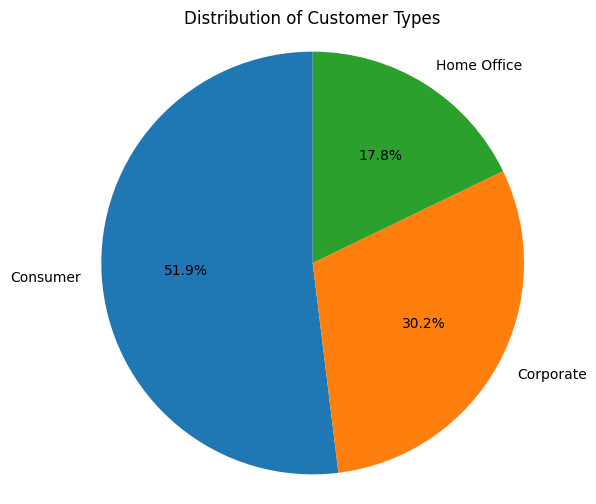

In [9]:
# Visualize
plt.figure(figsize=(6, 6))
plt.pie(
    number_of_customers['count'],
    labels=number_of_customers['Type of Customers'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribution of Customer Types")
plt.axis('equal')  # Ensures perfect circle

# Display the figure
plt.show()


>This visualization shows the proportion of customers across the three business segments: Consumer, Corporate, and Home Office. The Consumer segment represents the largest share of customers, indicating that individual buyers form the core of the customer base.

In [10]:
# Check total sales in each segment
sales_per_segment = df.groupby('Segment')['Sales'].sum().reset_index()
sales_per_segment = sales_per_segment.rename(columns={'Segment' : 'Type Of Customer', 'Sales' : 'Total Sales'})
print(sales_per_segment)


  Type Of Customer   Total Sales
0         Consumer  1.161401e+06
1        Corporate  7.061464e+05
2      Home Office  4.296531e+05


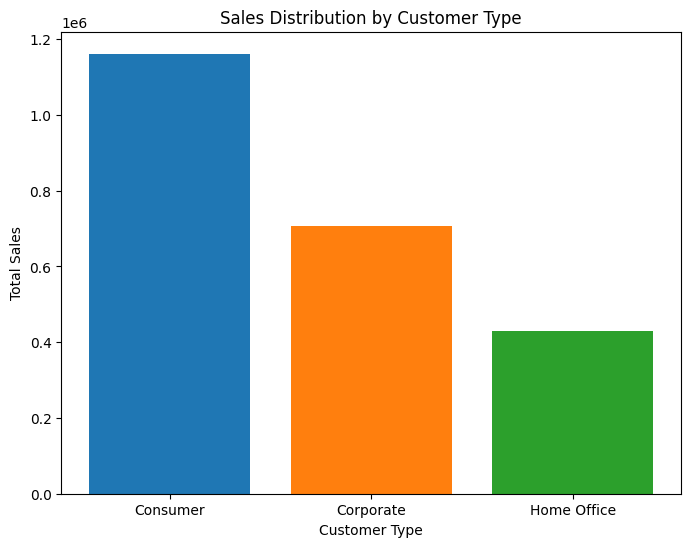

In [11]:
# Visualize
plt.figure(figsize=(8, 6))
colors = plt.cm.tab10(np.arange(len(sales_per_segment)))
plt.bar(
    sales_per_segment['Type Of Customer'],
    sales_per_segment['Total Sales'],
    color=colors
)
plt.title("Sales Distribution by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.show()


>This chart compares total sales generated by each customer segment. The Consumer segment contributes the highest revenue, followed by Corporate and Home Office customers, highlighting where the majority of revenue originates

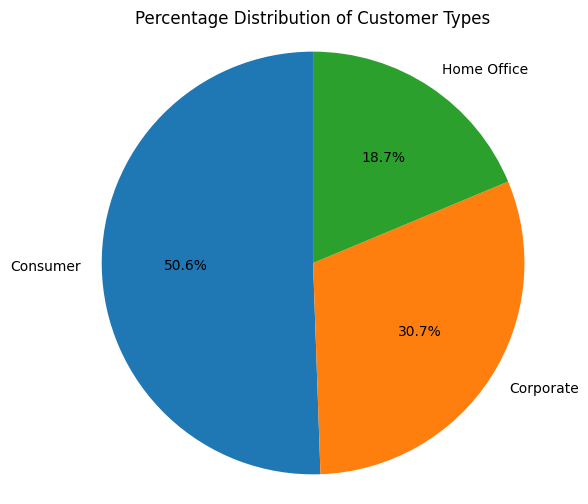

In [13]:
# Visualize
plt.figure(figsize=(6, 6))
plt.pie(
    sales_per_segment['Total Sales'],
    labels=sales_per_segment['Type Of Customer'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Percentage Distribution of Customer Types")
plt.axis('equal')  # Ensures perfect circle

# Display the figure
plt.show()


>This chart compares the percentage of total sales generated by each customer segment. The Consumer segment contributes the highest revenue, followed by Corporate and Home Office customers, highlighting where the majority of revenue originates

- #### Analyze repeat purchase behavior to infer customer lifetime value (CLTV).

In [14]:
# preview data
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [15]:
customers_order_frequency = df.groupby(['Customer ID', 'Customer Name', 'Segment'])['Order ID'].count().reset_index()

In [16]:
customers_order_frequency.rename(columns={'Order ID' : 'Total Orders'}, inplace = True)

In [17]:
repeat_customers = customers_order_frequency[customers_order_frequency['Total Orders'] >= 1]

In [18]:
repeat_customers_sorted = repeat_customers.sort_values(by= 'Total Orders', ascending = False)

In [19]:
print(repeat_customers_sorted.head(12).reset_index(drop=True))

   Customer ID        Customer Name      Segment  Total Orders
0     WB-21850        William Brown     Consumer            37
1     PP-18955           Paul Prost  Home Office            34
2     JL-15835             John Lee     Consumer            34
3     MA-17560         Matt Abelman  Home Office            34
4     SV-20365          Seth Vernon     Consumer            32
5     JD-15895     Jonathan Doherty    Corporate            32
6     CK-12205  Chloris Kastensmidt     Consumer            32
7     EH-13765         Edward Hooks    Corporate            32
8     EP-13915           Emily Phan     Consumer            31
9     ZC-21910     Zuschuss Carroll     Consumer            31
10    AP-10915       Arthur Prichep     Consumer            31
11    LC-16870        Lena Cacioppo     Consumer            30


>This table highlights customers with the highest number of repeat purchases. Frequent buyers indicate strong customer loyalty and represent high lifetime value customers.

- #### Highlight high-frequency and high-spending customers.

In [20]:
# Top spending customer
customer_sales = df.groupby(['Customer ID', 'Customer Name', 'Segment'])['Sales'].sum().reset_index()
top_spenders = customer_sales.sort_values(by='Sales', ascending=False)

print(top_spenders.head(12).reset_index(drop=True))

   Customer ID       Customer Name      Segment      Sales
0     SM-20320         Sean Miller  Home Office  25043.050
1     TC-20980        Tamara Chand    Corporate  19052.218
2     RB-19360        Raymond Buch     Consumer  15117.339
3     TA-21385        Tom Ashbrook  Home Office  14595.620
4     AB-10105       Adrian Barton     Consumer  14473.571
5     KL-16645        Ken Lonsdale     Consumer  14175.229
6     SC-20095        Sanjit Chand     Consumer  14142.334
7     HL-15040        Hunter Lopez     Consumer  12873.298
8     SE-20110        Sanjit Engle     Consumer  12209.438
9     CC-12370  Christopher Conant     Consumer  12129.072
10    TS-21370        Todd Sumrall    Corporate  11891.751
11    GT-14710           Greg Tran     Consumer  11820.120


>This table from our analysis ranks customers by total sales value. It identifies high-value customers who contribute disproportionately to revenue and are critical for retention strategies.

### 2. Product and Category Performance Evaluation
- Assess sales performance at Category and Sub-Category levels.
- Identify top-performing products and underperforming segments.

- #### Assess sales performance at Category and Sub-Category levels.

In [21]:
# Preview data
df.head(4)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310


In [22]:
# Check product main category
products = df['Category'].unique()
print(products)

['Furniture' 'Office Supplies' 'Technology']


In [23]:
# Check product subcategory
product_subcategory = df['Sub-Category'].unique()
print(product_subcategory)

['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


In [24]:
# check product subcategory count
subcategory_count = df.groupby('Category')['Sub-Category'].nunique().reset_index()
subcategory_count = subcategory_count.sort_values(by='Sub-Category', ascending = False)
print(subcategory_count)

          Category  Sub-Category
1  Office Supplies             9
0        Furniture             4
2       Technology             4


In [25]:
# Check top performing subcategory in total sales
subcategory_count_sales = df.groupby(['Category', 'Sub-Category'])['Sales'].sum().reset_index()
subcategory_count_sales = subcategory_count_sales.sort_values(by='Sales', ascending = False)
print(subcategory_count_sales)

           Category Sub-Category        Sales
16       Technology       Phones  330007.0540
1         Furniture       Chairs  328449.1030
11  Office Supplies      Storage  223843.6080
3         Furniture       Tables  206965.5320
6   Office Supplies      Binders  203412.7330
15       Technology     Machines  189238.6310
13       Technology  Accessories  167380.3180
14       Technology      Copiers  149528.0300
0         Furniture    Bookcases  114879.9963
4   Office Supplies   Appliances  107532.1610
2         Furniture  Furnishings   91705.1640
10  Office Supplies        Paper   78479.2060
12  Office Supplies     Supplies   46673.5380
5   Office Supplies          Art   27118.7920
7   Office Supplies    Envelopes   16476.4020
9   Office Supplies       Labels   12486.3120
8   Office Supplies    Fasteners    3024.2800


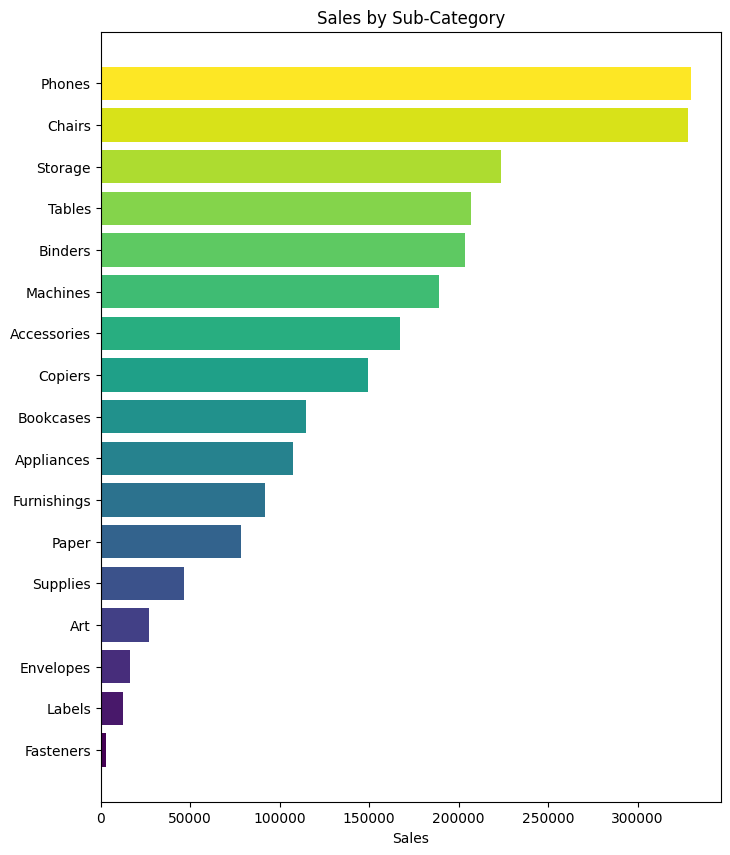

In [26]:
# Visualize
subcategory_count_sales = subcategory_count_sales.sort_values(by='Sales', ascending=True)

plt.figure(figsize=(8, 10))
plt.barh(
    subcategory_count_sales['Sub-Category'],
    subcategory_count_sales['Sales'],
    color=plt.cm.viridis(np.linspace(0, 1, len(subcategory_count_sales)))
)
plt.title("Sales by Sub-Category")
plt.xlabel("Sales")

plt.show()


>Our analysis highlights sub-categories contributing the most revenue. Phones and Chairs emerge as top-performing products, while smaller office supply items contribute marginally.

- #### Identify top-performing products and underperforming segments.

In [27]:
# top performing main category
product_category = df.groupby(['Category'])['Sales'].sum().reset_index()
top_product_category  = product_category.sort_values(by='Sales', ascending = False)
print(top_product_category.reset_index(drop=True) )

          Category        Sales
0       Technology  836154.0330
1        Furniture  741999.7953
2  Office Supplies  719047.0320


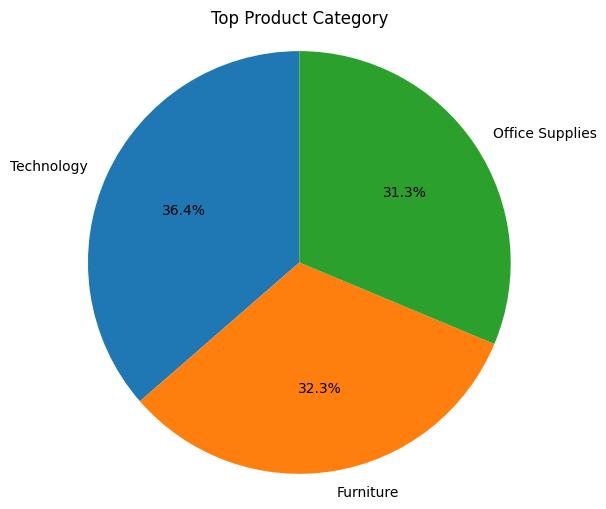

In [60]:
# Visualize
plt.figure(figsize=(6, 6))
plt.pie(
    top_product_category['Sales'],
    labels=top_product_category['Category'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Top Product Category")
plt.axis('equal')  # Ensures perfect circle

# Display the figure
plt.show()


>This chart compares sales across main product categories. Technology leads overall sales, followed by Furniture and Office Supplies, emphasizing the importance of tech-related products

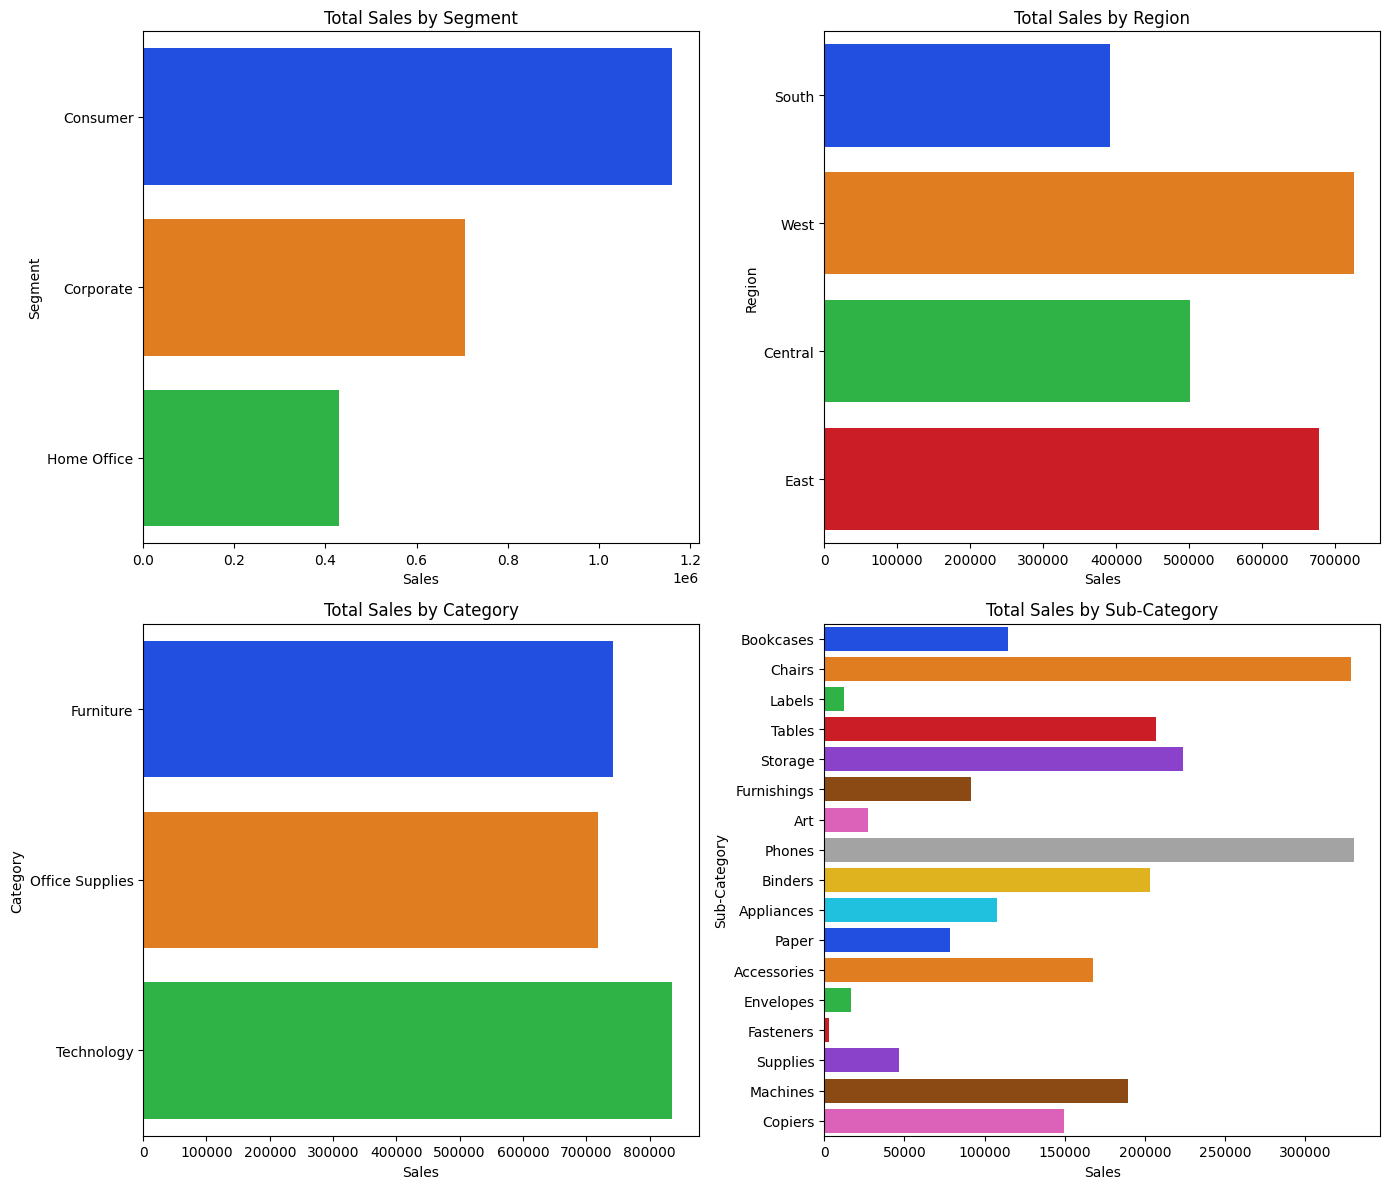

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
columns = ['Segment', 'Region', 'Category', 'Sub-Category']

for i, column in enumerate(columns):
    ax = axes[i // 2, i % 2]
    sns.barplot(
        x='Sales',
        y=column,
        data=df,
        estimator=np.sum,
        errorbar=None,
        palette='bright',
        ax=ax
    )
    ax.set_title(f"Total Sales by {column}")

plt.tight_layout()
plt.show()


>These visualizations break down total sales across key business dimensions. They provide a comparative view of performance by customer segment, geography, and product hierarchy.

### 3. Geographic Performance Assessment¶
- Analyze customer distribution and sales performance across states and cities.
- Visualize regional sales concentration using bar charts and choropleth maps.

* #### Analyze customer distribution and sales performance across states and cities.

In [30]:
# Top performing states
state = df['State'].value_counts().reset_index()
state = state.rename(columns={'count' : 'State', 'State': 'Number Of Customers'})
print(state.head(20))


   Number Of Customers  State
0           California   2001
1             New York   1128
2                Texas    985
3         Pennsylvania    587
4           Washington    506
5             Illinois    492
6                 Ohio    469
7              Florida    383
8             Michigan    255
9       North Carolina    249
10             Arizona    224
11            Virginia    224
12             Georgia    184
13           Tennessee    183
14            Colorado    182
15             Indiana    149
16            Kentucky    139
17       Massachusetts    135
18          New Jersey    130
19              Oregon    124


>This table shows customer distribution across states. California, New York, and Texas have the highest customer counts, indicating strong market presence in these regions.

In [31]:
# Sales Per State
state_sales = df.groupby(['State'])['Sales'].sum().reset_index()
top_state_sales = state_sales.sort_values(by='Sales', ascending=False)
print(top_state_sales.head(10).reset_index(drop=True))


          State        Sales
0    California  457687.6315
1      New York  310876.2710
2         Texas  170188.0458
3    Washington  138641.2700
4  Pennsylvania  116511.9140
5       Florida   89473.7080
6      Illinois   80166.1010
7          Ohio   78258.1360
8      Michigan   76269.6140
9      Virginia   70636.7200


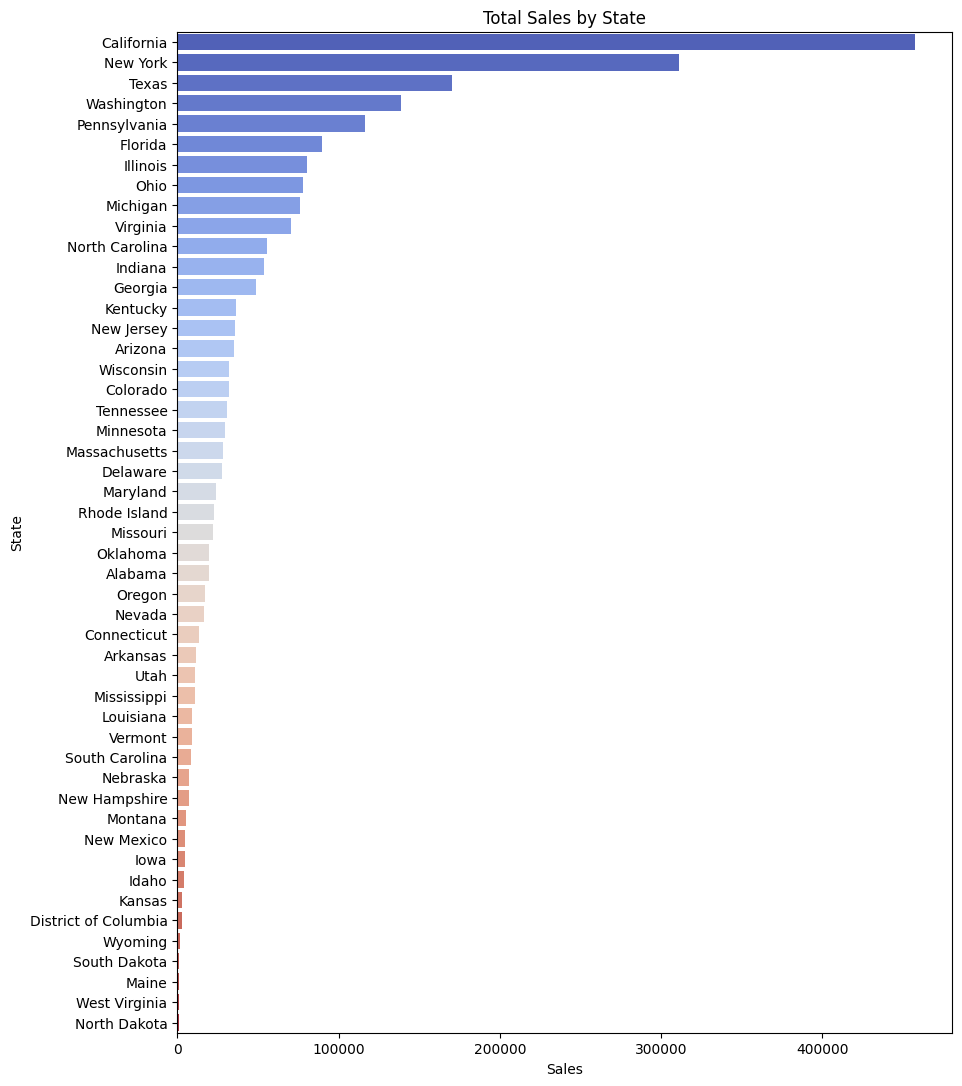

In [32]:
# Group by state and calculate the sum of sales
sum_of_sales = df.groupby('State')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)

# Create a horizonatl bar graph
plt.figure(figsize=(10, 13))
sns.barplot(
    x='Sales',
    y='State',
    data=sum_of_sales,
    palette='coolwarm',
    errorbar=None
)
plt.title("Total Sales by State")
plt.show()


>This visualization compares total sales across U.S. states. California leads significantly, followed by New York and Texas, identifying the most revenue-generating markets.

In [33]:
# Top City
city = df['City'].value_counts().reset_index()
city = city.rename(columns={'count' : 'Number Of Customers', 'City': 'Cities'})
print(city.head(20))

           Cities  Number Of Customers
0   New York City                  915
1     Los Angeles                  747
2    Philadelphia                  537
3   San Francisco                  510
4         Seattle                  428
5         Houston                  377
6         Chicago                  314
7        Columbus                  222
8       San Diego                  170
9     Springfield                  163
10         Dallas                  157
11   Jacksonville                  125
12        Detroit                  115
13         Newark                   95
14       Richmond                   90
15        Jackson                   82
16       Columbia                   81
17         Aurora                   68
18        Phoenix                   63
19     Long Beach                   61


>This table highlights cities with the largest customer base. New York City and Los Angeles dominate, reflecting high urban demand and population-driven sales concentration.

In [34]:
# Sales Per City by total sales
city_sales = df.groupby(['City'])['Sales'].sum().reset_index()
top_city_sales = city_sales.sort_values(by='Sales', ascending=False)
print(top_city_sales.head(10).reset_index(drop=True))

            City        Sales
0  New York City  256368.1610
1    Los Angeles  175851.3410
2        Seattle  119540.7420
3  San Francisco  112669.0920
4   Philadelphia  109077.0130
5        Houston   64504.7604
6        Chicago   48539.5410
7      San Diego   47521.0290
8   Jacksonville   44713.1830
9    Springfield   43054.3420


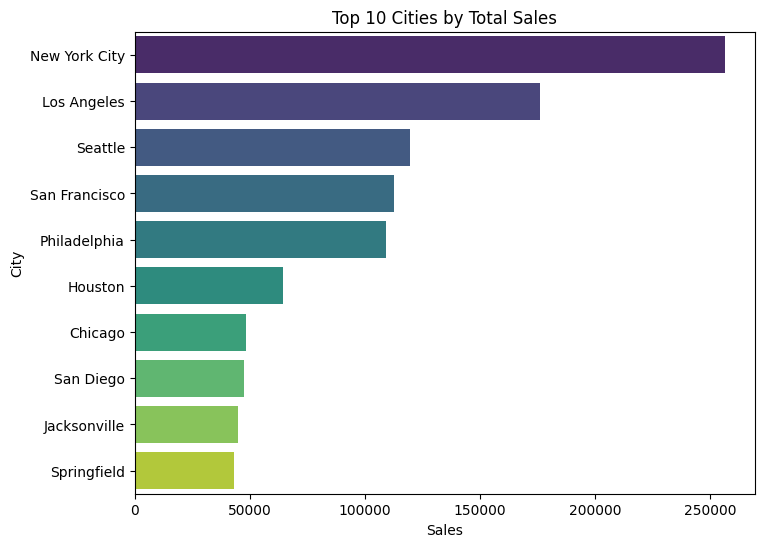

In [35]:
# Visualize
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Sales',
    y='City',
    data=top_city_sales.head(10),
    palette='viridis'
)
plt.title("Top 10 Cities by Total Sales")
plt.show()


>This chart shows cities ranked by total sales. New York City is the top-performing city, indicating a strong correlation between customer density and revenue.

* #### Visualize regional sales concentration using bar charts and choropleth maps.

In [36]:
df.sample()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1783,1784,CA-2017-166317,9/22/2017,9/26/2017,Standard Class,JE-15610,Jim Epp,Corporate,United States,Milwaukee,...,53209,Central,OFF-PA-10004475,Office Supplies,Paper,Xerox 1940,219.84,4,0.0,107.7216


In [37]:
# Top performing Region
region = df['Region'].value_counts().reset_index()
region = region.rename(columns={'count' : 'Number of Customers', 'Region': 'Region'})
print(region)



    Region  Number of Customers
0     West                 3203
1     East                 2848
2  Central                 2323
3    South                 1620


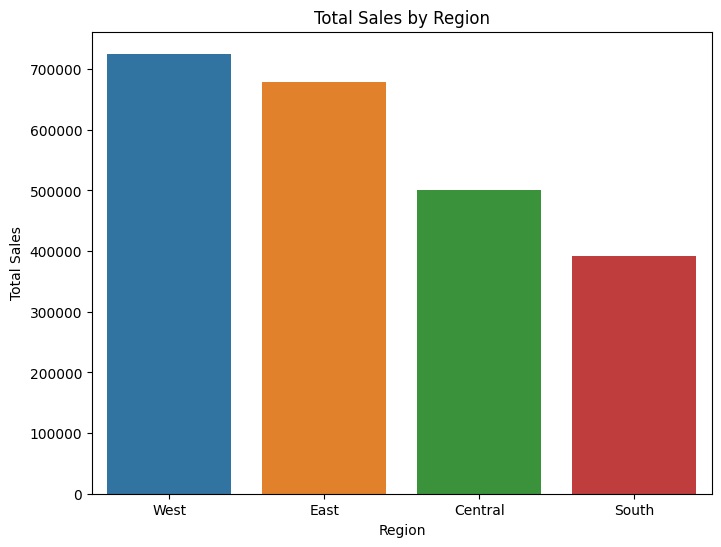

In [61]:
# Aggregate sales per region
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
top_region_sales = region_sales.sort_values(by='Sales', ascending=False)

# Visualize
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Region',
    y='Sales',
    data=top_region_sales,
    palette='tab10'
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()


>The West and East regions generate the highest total sales, indicating stronger market demand or better distribution efficiency. The Central and South regions lag behind, suggesting potential opportunities for regional sales strategy optimization.

In [39]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Initialize Plotly in Jupyter Notebook mode
import plotly.io as pio

# Create a mapping for all 50 states
all_state_mapping = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL",
    "Indiana": "IN", "Iowa": "IA", "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA",
    "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT",
    "Virginia": "VA", "Washington": "WA", "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
}

# Add abbreviation column to the Dataframe
df['Abbreviation'] = df['State'].map(all_state_mapping)

# Group by state and calculate the sum of sales
sum_of_sales = df.groupby('State')['Sales'].sum().reset_index()

# Add Abbreviation to sum_of_sale
sum_of_sales['Abbreviation'] = sum_of_sales['State'].map(all_state_mapping)

# Create a choropleth map using Plotly
fig = go.Figure(data=go.Choropleth(
    locations=sum_of_sales['Abbreviation'],
    locationmode='USA-states',
    z=sum_of_sales['Sales'],
    hoverinfo='location+z',
    colorscale='Blues'
))

fig.update_geos(projection_type="albers usa")
fig.update_layout(title='Total Sales by U.S. State')

fig.show()


>The choropleth map visualizes sales intensity across U.S. states. Darker regions such as California and New York represent higher sales concentrations, enabling quick geographic comparison.

### 4. Shipping and Operational Insights¶
- Determine customer preferences across different shipping modes.
- Evaluate how shipping modes affect delivery time, sales volume, and profitability—and identify operational trade-offs.

* #### Determine customer preferences across different shipping modes.

In [40]:
# Check data columns
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Abbreviation'],
      dtype='object')

In [41]:
# Preferred Shipping Method
shipping_mode = df['Ship Mode'].value_counts().reset_index()
shipping_mode = shipping_mode.rename(columns={'count' : 'Use Frequency', 'Ship Mode' : 'Mode Of Shipment'})
print(shipping_mode)

  Mode Of Shipment  Use Frequency
0   Standard Class           5968
1     Second Class           1945
2      First Class           1538
3         Same Day            543


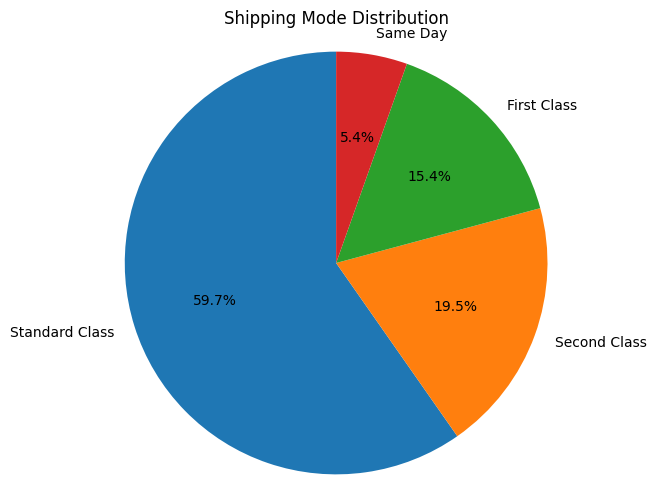

In [42]:
# Visualize
plt.figure(figsize=(6, 6))
plt.pie(
    shipping_mode['Use Frequency'],
    labels=shipping_mode['Mode Of Shipment'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Shipping Mode Distribution")
plt.axis('equal')

plt.show()

>This chart displays the frequency of each shipping mode. Standard Class is overwhelmingly preferred, suggesting that customers prioritize cost efficiency over faster delivery options.

* #### Evaluate how shipping modes affect delivery time, sales volume, and profitability—and identify operational trade-offs.

In [43]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Abbreviation
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,KY
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,KY
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,CA
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,FL
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,FL


In [44]:
#----------------------Derive Key Shipping Metrics----------

# Convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Shipping lead time (days)
df['Shipping Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days


In [45]:
#--------------------- Analyze Shipping Mode Performance --------------

# A. Speed vs Cost Proxy (Lead Time
shipping_perf = df.groupby('Ship Mode').agg(
    avg_lead_time=('Shipping Lead Time', 'mean'),
    total_sales=('Sales', 'sum'),
    avg_profit=('Profit', 'mean'),
    total_orders=('Order ID', 'count')
).reset_index()


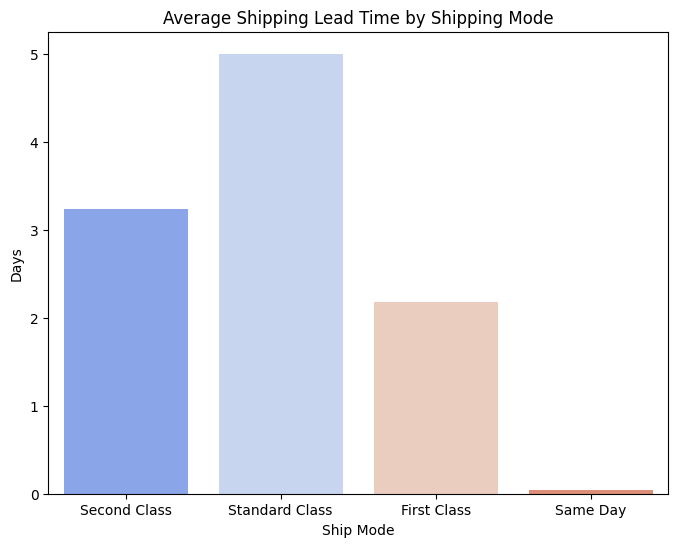

In [62]:
# B. Visualize Lead Time by Shipping Mode
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Ship Mode',
    y='Shipping Lead Time',
    data=df,
    errorbar=None,
    palette='coolwarm'
)
plt.title("Average Shipping Lead Time by Shipping Mode")
plt.ylabel("Days")

plt.show()


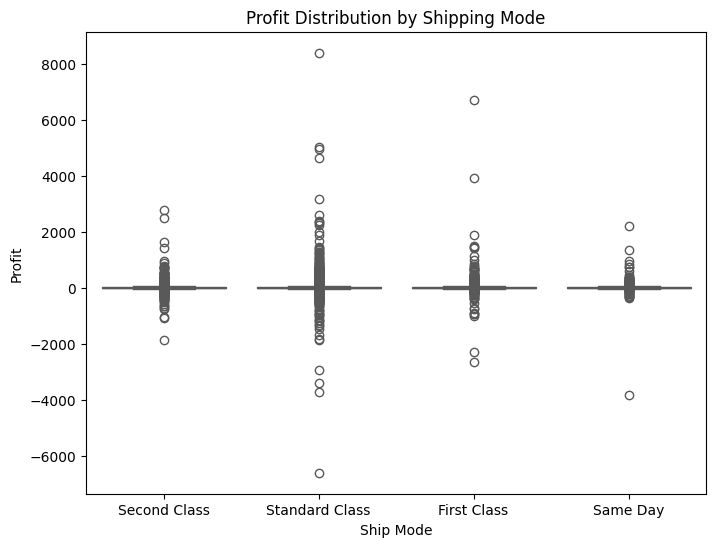

In [47]:
#--------------------- Profitability Impact of Shipping Choices --------------
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='Ship Mode',
    y='Profit',
    data=df,
    palette='Set2'
)
plt.title("Profit Distribution by Shipping Mode")
plt.show()


>This visualization shows how profit varies across different shipping modes. While all modes exhibit a wide range of outcomes, *Standard Class* and *First Class* display the greatest variability, with both high-profit outliers and significant losses. *Same Day* and *Second Class* shipping tend to have tighter profit distributions, indicating more consistent but generally lower profit impacts. Overall, the chart highlights that faster or commonly used shipping modes can drive higher profits but also introduce greater risk of losses, emphasizing the need for careful alignment between shipping choice and order profitability.


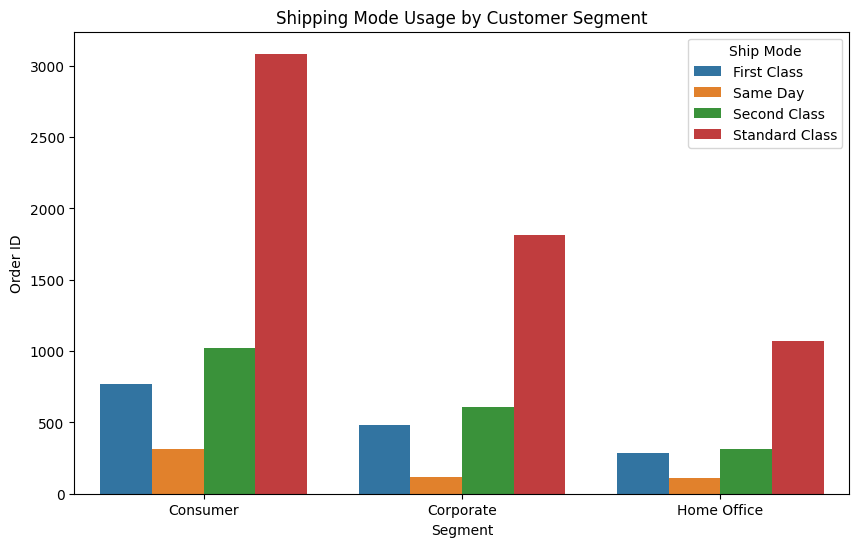

In [64]:
#--------------------- Customer Segment Dependency (Operational Risk) --------------
segment_shipping = df.groupby(['Segment', 'Ship Mode'])['Order ID'].count().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Segment',
    y='Order ID',
    hue='Ship Mode',
    data=segment_shipping,
    palette='tab10'
)
plt.title("Shipping Mode Usage by Customer Segment"))
plt.show()


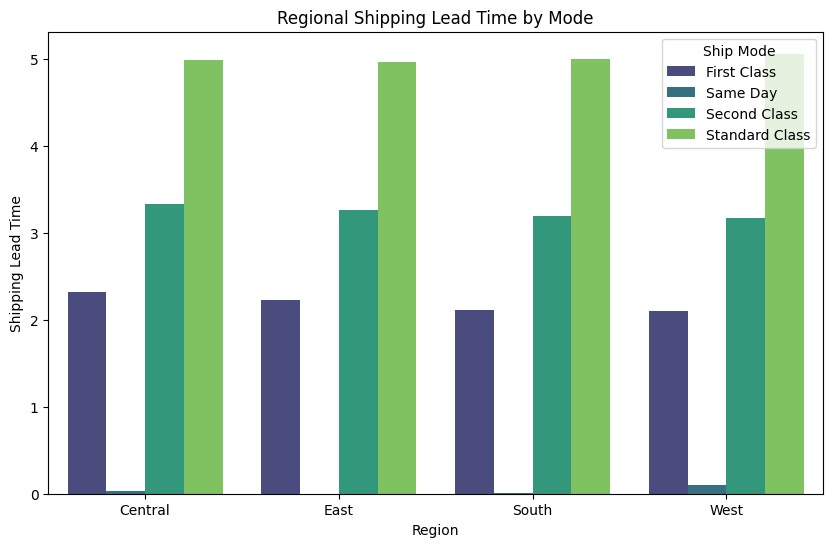

In [63]:
# Regional Shipping Stress Test
region_shipping = df.groupby(['Region', 'Ship Mode'])['Shipping Lead Time'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Region',
    y='Shipping Lead Time',
    hue='Ship Mode',
    data=region_shipping,
    palette='viridis'
)
plt.title("Regional Shipping Lead Time by Mode")

plt.show()


**Operational Evaluation of Shipping Behavior**

>Analysis shows that expedited shipping modes significantly reduce lead time but are associated with lower average profit margins. Standard shipping offers the best balance between delivery speed and profitability, especially for Consumer and Home Office segments. Regional disparities in shipping lead time indicate fulfillment inefficiencies in the South and Central regions, suggesting opportunities for warehouse optimization or carrier renegotiation.

### 5. Time Series and Trend Analysis
- Examine yearly, quarterly, and monthly sales trends.
- Identify seasonality and growth patterns to inform forecasting.

* #### Examine yearly, quarterly, and monthly sales trend

In [50]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Abbreviation', 'Shipping Lead Time'],
      dtype='object')

In [51]:
# Yearly Sales
df['Order Date'] = pd.to_datetime(df['Order Date']) # dayfirst = True)
yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum()
yearly_sales = yearly_sales.reset_index()
yearly_sales = yearly_sales.rename(columns={'Order Date' : 'Year', 'Sales' : 'Total Sales'})

print(yearly_sales)

   Year  Total Sales
0  2014  484247.4981
1  2015  470532.5090
2  2016  609205.5980
3  2017  733215.2552


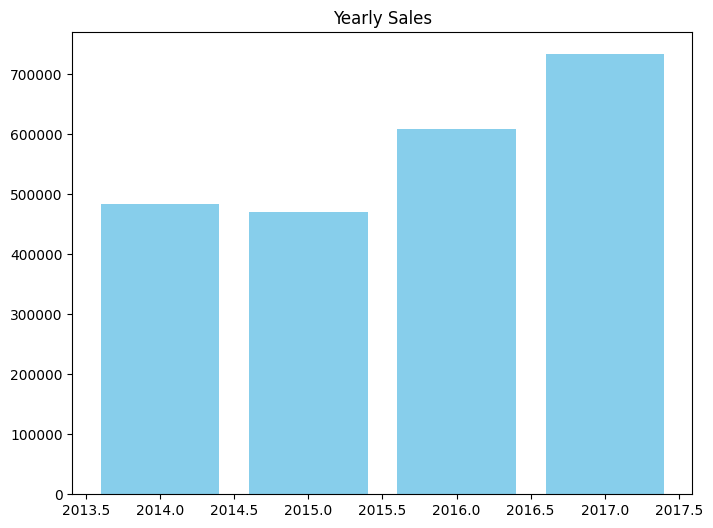

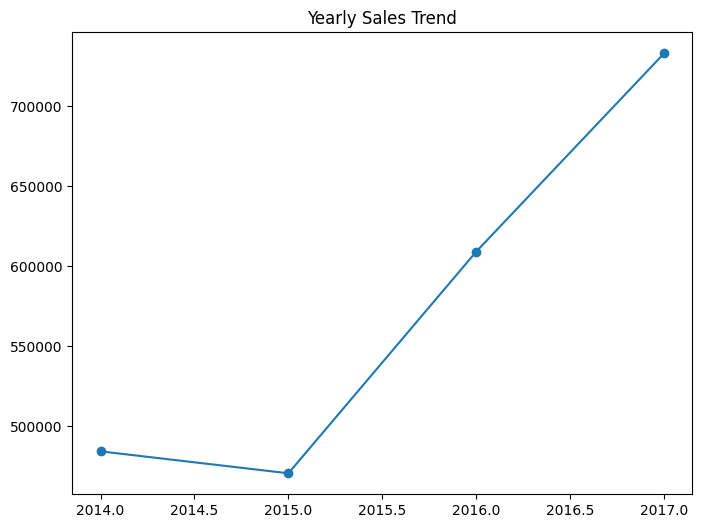

In [52]:
plt.figure(figsize=(8, 6))
plt.bar(yearly_sales['Year'], yearly_sales['Total Sales'], color='skyblue')
plt.title("Yearly Sales")
plt.show()


plt.figure(figsize=(8, 6))
plt.plot(yearly_sales['Year'], yearly_sales['Total Sales'], marker='o')
plt.title("Yearly Sales Trend")
plt.show()


>This visualization from our analysis shows annual sales performance from 2014 to 2017. Sales demonstrate a strong upward trend, with peak performance in 2017, indicating consistent business growth.

In [53]:
# Quarterly sale
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst = True)
yearly_sales = df[df['Order Date'].dt.year==2017]
quarterly_sales = yearly_sales.resample('QE', on='Order Date')['Sales'].sum()
quarterly_sales = quarterly_sales.reset_index()

quarterly_sales = quarterly_sales.rename(columns = {'Order Date' : 'Quarter', 'Sales' : 'Total Sales'})

print(quarterly_sales)


     Quarter  Total Sales
0 2017-03-31  123144.8602
1 2017-06-30  133764.3720
2 2017-09-30  196251.9560
3 2017-12-31  280054.0670


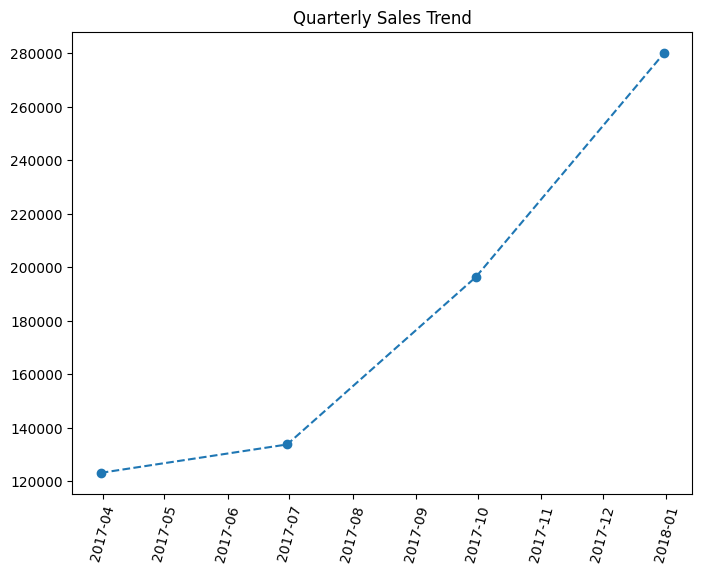

In [54]:
plt.figure(figsize=(8, 6))
plt.plot(quarterly_sales['Quarter'], quarterly_sales['Total Sales'], marker='o', linestyle='--')
plt.xticks(rotation=75)
plt.title("Quarterly Sales Trend")
plt.show()


>We analyzed quarterly sales for 2017. From our analysis, we can see that sales increase steadily throughout the year, with a sharp peak in Q4, suggesting strong seasonality toward year-end.

In [55]:
# Monthly Sales
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst = True)
yearly_sales = df[df['Order Date'].dt.year==2017]
monthly_sales = yearly_sales.resample('ME', on='Order Date')['Sales'].sum()
monthly_sales = monthly_sales.reset_index()
monthly_sales = monthly_sales.rename(columns = {'Order Date' : 'Month', 'Sales' : 'Total Monthly Sales'})

print(monthly_sales)

        Month  Total Monthly Sales
0  2017-01-31           43971.3740
1  2017-02-28           20301.1334
2  2017-03-31           58872.3528
3  2017-04-30           36521.5361
4  2017-05-31           44261.1102
5  2017-06-30           52981.7257
6  2017-07-31           45264.4160
7  2017-08-31           63120.8880
8  2017-09-30           87866.6520
9  2017-10-31           77776.9232
10 2017-11-30          118447.8250
11 2017-12-31           83829.3188


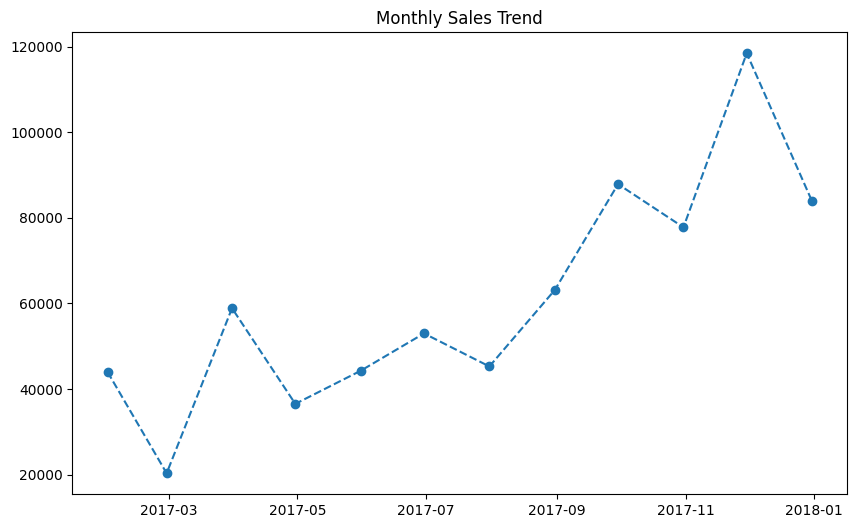

In [56]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_sales['Month'], monthly_sales['Total Monthly Sales'], marker='o', linestyle='--')
plt.title("Monthly Sales Trend")
plt.show()


>This visualization breaks down monthly sales for 2017. November and December show the highest sales volumes, reinforcing the presence of holiday-driven demand.

### 6. Executive-Level Visualization and Storytelling¶
- Develop intuitive visualizations to support data-driven decision-making.
- Present insights in a format suitable for business stakeholders.

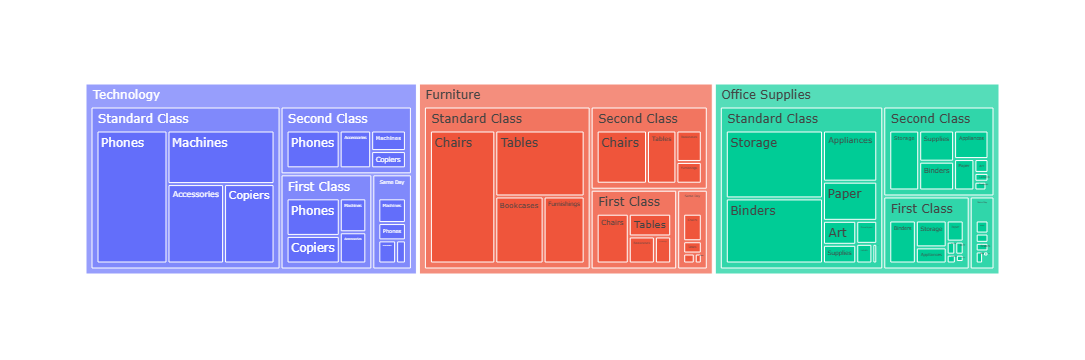

In [67]:
# Summarise the Sales data by Category, Ship Mode and Sub-Category

df_summary = df.groupby(['Category', 'Ship Mode', 'Sub-Category'])['Sales'].sum().reset_index()

# Create a treemap
fig = px.treemap(df_summary, path=['Category', 'Ship Mode', 'Sub-Category'], values='Sales')

fig.show()

>This treemap illustrates how sales are distributed across product categories, shipping methods, and sub-categories, offering insight into how logistics interact with product performance.

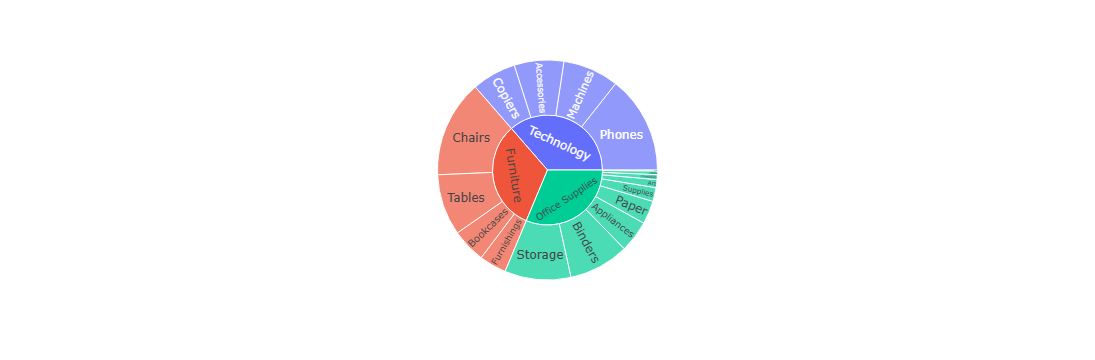

In [58]:
# Summarise the Sales data by Category and Sub-Category
df_summary = df.groupby(['Category', 'Sub-Category'])['Sales'].sum().reset_index()

# Create a nested pie chart
fig = px.sunburst(
    df_summary, path=['Category', 'Sub-Category'], values='Sales')

fig.show()

> This visualization provides a hierarchical view of sales by category and sub-category. It clearly shows how revenue is distributed within each product category.

## Key Results and Findings

* The **Consumer segment** is the primary revenue driver and customer base.
* **Technology products**, particularly **Phones**, generate the highest sales.
* **California and New York** dominate both customer volume and revenue.
* **Standard Class shipping** is the most cost-effective and widely used option.
* Sales exhibit **strong seasonality**, peaking in **Q4**, especially in November.
* A small group of customers accounts for a **disproportionate share of revenue**, indicating high CLTV concentration.

---

## Business Recommendations

1. **Prioritize Consumer Segment Marketing**
   Allocate more marketing and retention resources toward Consumer customers, as they generate the majority of sales and repeat purchases.

2. **Double Down on High-Performing Products**
   Increase inventory availability and promotional focus on Technology products—especially Phones—to maximize revenue growth.

3. **Geographic Sales Optimization**
   Strengthen regional strategies in California and New York while exploring targeted growth initiatives in high-potential states like Texas and Washington.

4. **Seasonal Planning and Forecasting**
   Prepare inventory, staffing, and marketing campaigns ahead of Q4 to capitalize on peak demand periods.

5. **Customer Retention Strategies**
   Develop loyalty programs or personalized offers for top-spending and repeat customers to protect high lifetime value relationships.

6. **Shipping Cost Optimization**
   Maintain Standard Class as the default option while selectively promoting faster shipping for high-value orders.

---